In [2]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({'font.size': 16})
import pandas as pd
import random as rand
np.seterr(divide='ignore', invalid='ignore')

{'divide': 'warn', 'over': 'warn', 'under': 'ignore', 'invalid': 'warn'}

In [20]:
#soil moisture loss function
def loss_func (ET_max,ET_w,n,Zr,sh,sw,s1,sfc,ss):
    if (ss <= sh):
        losses = 0
    elif ((ss > sh) and (ss <= sw)):
        losses = (ET_w/(n*Zr))*((ss-sh)/(sw-sh))
    elif ((ss > sw) and (ss <= s1)):
        losses = (ET_w + (ET_max - ET_w)*((ss-sw)/(s1-sw)))/(n*Zr)
    elif ((ss > s1) and (ss <= sfc)):
        losses = (ET_max/(n*Zr))
    else:
        losses = (ET_max/(n*Zr))+(1/(n*Zr))*(Ks/(np.exp(beta*(1-sfc))-1) * ((np.exp(beta*(ss-sfc))) - 1 ))
        
    return losses

# Soil Properties
def soil(x):
    if x == "loamy sand":
        n = 0.42 # soil porosity [-],
        Zr = 30 # Depth of the rooting zone [cm]
        ET_max = 0.45 # maximum value of ET [cm/day]
        ET_w = 0.01 #  value of ET [mm/day] at wilting point
        phis = -0.17*10**-3 #(MPa)
        b = 4.38
        sfc = 0.52 # soil moisture at field capacity
        sw = 0.11 # wilting point
        sh = (phis/-10000)**(1/b) # soil moisture at hygroscopic point
        swh = (phis/-100)**(1/b)
        s1 = 0.31 # soil moisture at onset of plant stress
        beta = 12.7 # soil term to calculate K(s) decay as part of leakage term
        Ks = 100 # saturated hydraulic conductivity of the soil [K(ss=1)] (cm/day)        
        nn = 0.1362 # Normalization constant, so f[s] max =1
        km = 0.03    #(*microbial deposition rate*)
        hh = 0.92     #(*Influence of temperature on bacteria metabolism, Ehhalt and Roher(2011)*)
        sopt = (phis/-0.3)**(1/b)
        beta1 = 0.4
        beta2 = beta1*((1-sopt)/(sopt-swh))
        beta22 = beta1*((1-sopt)/(sopt-sw))
        
    elif x == "sand":
        n = 0.35 # soil porosity [-],
        Zr = 30 # Depth of the rooting zone [cm]
        ET_max = 0.45 # maximum value of ET [cm/day]
        ET_w = 0.01 #  value of ET [cm/day] at wilting point
        phis = -0.34*10**-3 #(MPa)
        b = 4.05
        sfc = 0.35 # soil moisture at field capacity
        sw = 0.11 # wilting point
        sh = (phis/-10000)**(1/b) # soil moisture at hygroscopic point
        swh = (phis/-100)**(1/b)
        s1 = 0.33 # soil moisture at onset of plant stress
        beta = 12.1 # soil term to calculate K(s) decay as part of leakage term
        Ks = 200 # saturated hydraulic conductivity of the soil [K(ss=1)] (cm/day)        
        nn = 0.154 # Normalization constant, so f[s] max =1
        km = 0.03    #(*microbial deposition rate*)
        hh = 0.92     #(*Influence of temperature on bacteria metabolism, Ehhalt and Roher(2011)*)
        sopt = (phis/-0.3)**(1/b)
        beta1 = 0.4
        beta2 = beta1*((1-sopt)/(sopt-swh))
        beta22 = beta1*((1-sopt)/(sopt-sw))
        
    elif x == "loam":
        n = 0.45 # soil porosity [-],
        Zr = 30 # Depth of the rooting zone [cm]
        ET_max = 0.45 # maximum value of ET [cm/day]
        ET_w = 0.01 #  value of ET [cm/day] at wilting point
        phis = -1.43*10**-3 #(MPa)
        b = 5.39
        sfc = 0.65 # soil moisture at field capacity
        sw = 0.24 # wilting point
        sh = (phis/-10000)**(1/b) # soil moisture at hygroscopic point
        swh = (phis/-100)**(1/b)
        s1 = 0.57 # soil moisture at onset of plant stress
        beta = 13.8 # soil term to calculate K(s) decay as part of leakage term
        Ks= 20 # saturated hydraulic conductivity of the soil [K(ss=1)] (cm/day)
        nn = 0.18 # Normalization constant, so f[s] max =1
        km = 0.03    #(*microbial deposition rate*)
        hh = 0.92     #(*Influence of temperature on bacteria metabolism, Ehhalt and Roher(2011)*)
        sopt = (phis/-0.3)**(1/b)
        beta1 = 0.4
        beta2 = beta1*((1-sopt)/(sopt-swh))
        beta22 = beta1*((1-sopt)/(sopt-sw))
        
    else:
        pass
    return n,b, Zr, ET_max, ET_w, sfc, sw, sh,swh, s1, beta, Ks, nn, km, hh, beta1,sopt, beta2, beta22

# Response of biotic H2 consuming bacteria to soil moisture 
def fh(ss):
    if ss <= swh:
        fs=0
    else:
        fs = (((ss-swh)**beta1)*((1-ss)**beta2))/(((sopt-swh)**beta1)*((1-sopt)**beta2))
    return fs

def fhm(ss):
    if ss <= sw:
        fs=0
    else:
        fs = (((ss-sw)**beta1)*((1-ss)**beta22))/(((sopt-sw)**beta1)*((1-sopt)**beta22))
    return fs

# Response of Organic Carbon consuming bacteria to soil moisture
def fc(ss):
    if ss <= sw:
        fs=0
    elif sw < ss <= sfc:
        fs = (ss - sw)/(sfc - sw)
    else:
        fs = sfc/ss
    return fs
#total conductance of the soil and diffusive barrier
def gt(s,d,sp):
    D0 = 0.756
    a1 = 1 #alpha1
    a2 = 2 #alpha2
    a3 = 2+3/b
    gs = D0 * a1 * (n**a2) * (1-s)**a3
    gd = D0 * a1 * (sp**a2)/d
    #gt = ((n**2)*((1-ss)**(2+3/4.38))*(0.5**2)*0.756)/((n**2)*((1-ss)**(2+3/4.38)) +(0.5**2))
    gt = (gs * gd)/(gs + gd)
    return gt

# H2 Diffusive flux
def ff(ss,d,H, sp):
    ff = gt(ss, d, sp)*(Ha-H)
    return ff

# h2 biological sink
def bd(s, Cs, Bh):
    bd = hh*khh*fh(s)*Cs*Bh
    return bd

# Velocity that indicates the potential bological sink along depth Zr
def vbd(s, Cs, Bh):
    vbd = Zr*bd(s, Cs, Bh)
    return vbd
# Quasi steady approximation of H2 conecntration in the soil
def hyd(s, Cs, Bh, d, sp):
    hyd = Ha/(1 + (vbd(s, Cs, Bh)/gt(s,d, sp)))
    return hyd

x = "loamy sand"
n, b, Zr, ET_max, ET_w, sfc, sw, sh,swh, s1, beta, Ks, nn, km, hh, beta1,sopt, beta2, beta22 = soil(x)

length = 500 # simulation time (days)
Ha = 530  #(*Atmospheric concentration of hydrogen* ppb)
dt = 0.1 # time interval (days)

s_vec = np.linspace(0,1,int(length/dt))


ADD_max = 3.2 #g/m3/day
ADD_min = 0 #g/m3/day
khh = 2*10**-4 # Potential decomposition rate for hydrogen (5 (low), 3.2, 2(up))
kcc = 2.2*10**-3 # Potential decomposition rate for carbon (1.5(low), 1.8, 2.2(up))
mc = 0.005 # Mortality rate for carbon microbes
mh = 0.005 # Mortality rate for Hydrogen microbes
rc = 0.5 # Respiration rate for Carbon microbes
rh = 0.5 # Respiration rate for Hydrogen microbes
q = 12*0.0072 # carbon to hydrogen ratio [C/H]

def ADD(s):
    ADD = ADD_max + (ADD_min - ADD_max)/(1 + (s/sfc)**3.31)
    return ADD

### Carbon substrate steady state

In [4]:
def cs1(s):
    kc = kcc*fc(s)*hh
    try:
        cs = mc/((1-rc)*kc)
    except ZeroDivisionError:
        cs = 1000
    return cs

def cs2(s):
    kh = khh*fh(s)*hh
    try:
        cs = mh/q*((1-rh)*kh*H2(s))
    except ZeroDivisionError:
        cs = 1000
    return cs

### Hydrogen steady state 

In [5]:
# H1 = Ha
def H2(s):
    try: 
        H = Ha - (Zr*ADD(s))/(q*gt(s, 0.1, 0.5)*rh)
    except ZeroDivisionError:
        H = "inf"    
    return H
def H3(s):
    kh = khh*fh(s)*hh
    kc = kcc*fc(s)*hh
    try: 
        H = mh*kc*(1-rc)/(q*mc*kh*(1-rh))
        if H>Ha:
            H = Ha
    except ZeroDivisionError:
        H = "inf"
    return H

In [21]:
hh3 = np.zeros(int(length/dt))

for i in range(int(length/dt)):
    hh3[i] = H3(s_vec[i])

(0.0, 550.0)

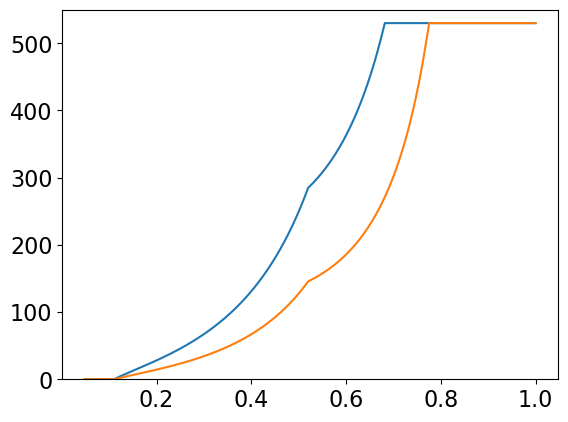

In [22]:
plt.plot(s_vec, hh3)
plt.plot(s_vec, h3)
#plt.scatter(ss, hh2, color = "k")
plt.ylim([0,550])

### HOB biomass steady state

In [7]:
# BH1 = 0
def Bh2(s):
    try:
        BH = ADD(s)*(1-rh)/(mh*rh)
    except ZeroDivisionError:
        BH = 0
    return BH

def Bh3(s):
    kh = khh*fh(s)*hh
    kc = kcc*fc(s)*hh
    try:
        BH = (-gt(s, 0.1, 0.5)*mh*kc*(1-rc) + gt(s, 0.1, 0.5)*q*Ha*kh*mc*(1-rh))/(mc*mh*kh*Zr)
        if BH == "NaN":
            BH = 0
        else:
            pass
    except ZeroDivisionError:
        BH = 0
    return BH

### CDB biomass steady state

In [6]:
# BC2 = 0
def Bc1(s):
    try:
        BC = ADD(s)*(1-rc)/(mc*rc)
    except ZeroDivisionError:
        BC = 0
    return BC

def Bc3(s):
    kh = khh*fh(s)*hh
    kc = kcc*fc(s)*hh
    try:
        BC = (1-rc)*(ADD(s) + mh*Bh3(s)*(1-(1/((1-rh)))))/(mc*rc)
        if BC == "NaN":
            BC = 0
    except ZeroDivisionError:
        BC = 0
    return BC

In [8]:
c1 = np.zeros(int(length/dt))
c2 = np.zeros(int(length/dt))
c3 = np.zeros(int(length/dt))
h1 = Ha*np.ones(int(length/dt))
h2 = np.zeros(int(length/dt))
h3 = np.zeros(int(length/dt))
bc1 = np.zeros(int(length/dt))
bc2 = np.zeros(int(length/dt))
bc3 = np.zeros(int(length/dt))
bh1 = np.zeros(int(length/dt))
bh2 = np.zeros(int(length/dt))
bh3 = np.zeros(int(length/dt))

#Vectors of solution
for i in range(int(length/dt)):
    c1[i] = cs1(s_vec[i])
    c2[i] = cs2(s_vec[i])
    h2[i] = H2(s_vec[i])
    h3[i] = H3(s_vec[i])
    bh2[i] = Bh2(s_vec[i])
    bh3[i] = Bh3(s_vec[i])
    bc1[i] = Bc1(s_vec[i])
    bc3[i] = Bc3(s_vec[i])
    
c3 = c1.copy()

In [23]:
# Upper bound
c1up = np.zeros(int(length/dt))
c2up = np.zeros(int(length/dt))
h1up = Ha*np.ones(int(length/dt))
h2up = np.zeros(int(length/dt))
h3up = np.zeros(int(length/dt))
bc1up = np.zeros(int(length/dt))
bc2up = np.zeros(int(length/dt))
bc3up = np.zeros(int(length/dt))
bh1up = np.zeros(int(length/dt))
bh2up = np.zeros(int(length/dt))
bh3up = np.zeros(int(length/dt))

#Vectors of solution
for i in range(int(length/dt)):
    c1up[i] = cs1(s_vec[i])
    c2up[i] = cs2(s_vec[i])
    h2up[i] = H2(s_vec[i])
    h3up[i] = H3(s_vec[i])
    bh2up[i] = Bh2(s_vec[i])
    bh3up[i] = Bh3(s_vec[i])
    bc1up[i] = Bc1(s_vec[i])
    bc3up[i] = Bc3(s_vec[i])

c3up = c1up.copy()

In [12]:
# lowper bound
c1low = np.zeros(int(length/dt))
c2low = np.zeros(int(length/dt))
h1low = Ha*np.ones(int(length/dt))
h2low = np.zeros(int(length/dt))
h3low = np.zeros(int(length/dt))
bc1low = np.zeros(int(length/dt))
bc2low = np.zeros(int(length/dt))
bc3low = np.zeros(int(length/dt))
bh1low = np.zeros(int(length/dt))
bh2low = np.zeros(int(length/dt))
bh3low = np.zeros(int(length/dt))

#Vectors of solution
for i in range(int(length/dt)):
    c1low[i] = cs1(s_vec[i])
    c2low[i] = cs2(s_vec[i])
    h2low[i] = H2(s_vec[i])
    h3low[i] = H3(s_vec[i])
    bh2low[i] = Bh2(s_vec[i])
    bh3low[i] = Bh3(s_vec[i])
    bc1low[i] = Bc1(s_vec[i])
    bc3low[i] = Bc3(s_vec[i])

c3low = c1low.copy()

(0.0, 1.0)

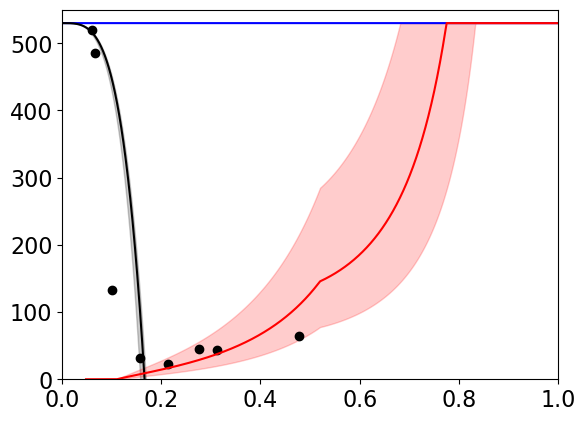

In [29]:
plt.plot(s_vec, h1, color = "blue")
plt.plot(s_vec, h2, color = "k")
plt.plot(s_vec, h3, color = "red")
plt.fill_between(s_vec, h2up, h2low, color = "k", alpha=0.2)
plt.fill_between(s_vec, h3up, h3low, color = "red", alpha=0.2)
plt.scatter(ss, hh2, color = "k")
#plt.scatter(ss, H_lin, color = "green")
plt.ylim([0,550])
plt.xlim([0,1])

(0.0, 1.0)

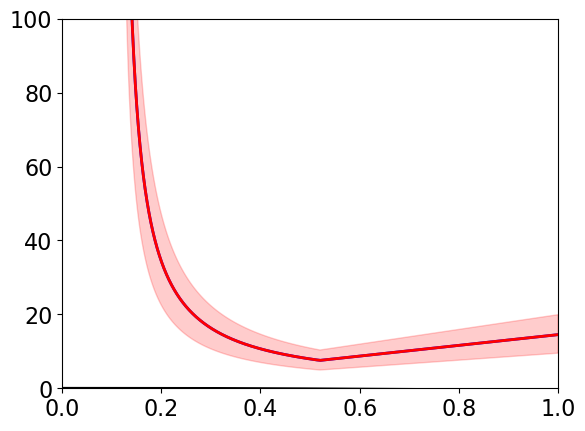

In [15]:

plt.plot(s_vec, c1, color = "blue", linewidth = 2)
plt.plot(s_vec, c2, color = "k",  linewidth = 2)
plt.plot(s_vec, c3, color = "red", linewidth = 2)
plt.fill_between(s_vec, c2up, c2low, color = "k", alpha=0.2)
plt.fill_between(s_vec, c3up, c3low, color = "red", alpha=0.2)
plt.ylim([0,100])
plt.xlim([0,1])

(0.0, 1.0)

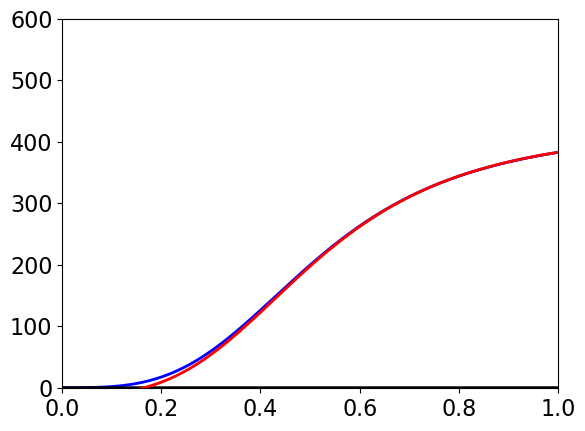

In [134]:
plt.plot(s_vec, bc1, color = "blue", linewidth = 2)
plt.plot(s_vec, bc2, color = "k", linewidth = 2)
plt.plot(s_vec, bc3, color = "red", linewidth = 2)
plt.fill_between(s_vec, bc1up, bc1low, color = "blue", alpha=0.2)
#plt.fill_between(s_vec, bc2up, bc2low, color = "k", alpha=0.2)
plt.fill_between(s_vec, bc3up, bc3low, color = "red", alpha=0.2)
plt.ylim([-1,600])
plt.xlim([0,1])

(0.0, 1.0)

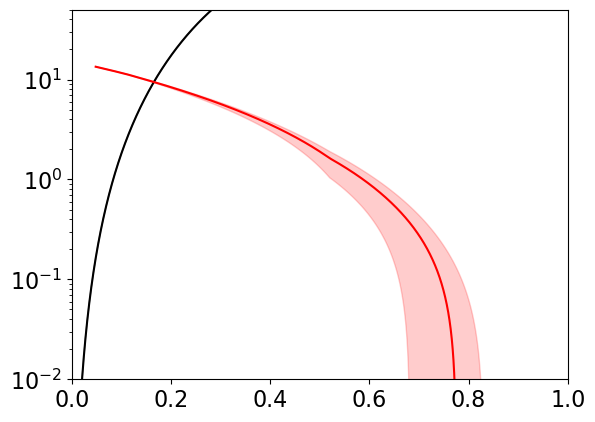

In [135]:
#plt.plot(s_vec, bh2, color = "blue")
plt.plot(s_vec, bh2, color = "k")
plt.semilogy(s_vec, bh3, color = "red")
plt.fill_between(s_vec, bh2up, bh2low, color = "k", alpha=0.2)
plt.fill_between(s_vec, bh3up, bh3low, color = "red", alpha=0.2)
plt.ylim([10**-2, 50])
plt.xlim([0,1])

In [147]:
np.where(h3==Ha)[0][0]

3876

(0.0, 100.0)

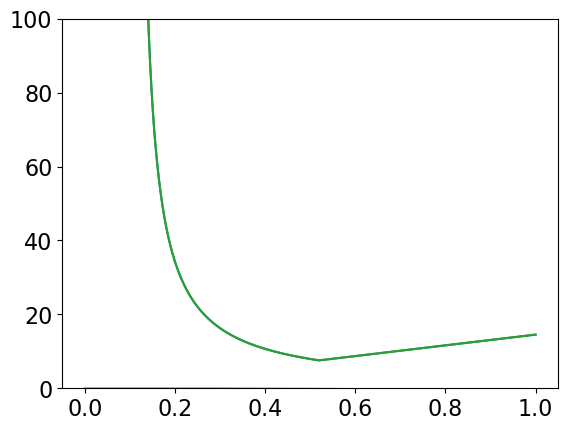

In [11]:
c3 = c1.copy()


plt.plot(s_vec,c1)
plt.plot(s_vec,c2)
plt.plot(s_vec,c3)
plt.ylim([0,100])

(0.0, 1.0)

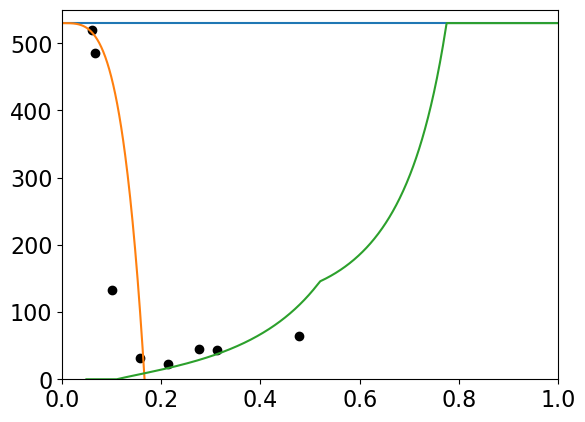

In [22]:
plt.plot(s_vec, h1)
plt.plot(s_vec, h2)
plt.plot(s_vec, h3)
plt.scatter(ss, hh2, color = "k")
plt.ylim([0,550])
plt.xlim([0,1])

(0.0, 1.0)

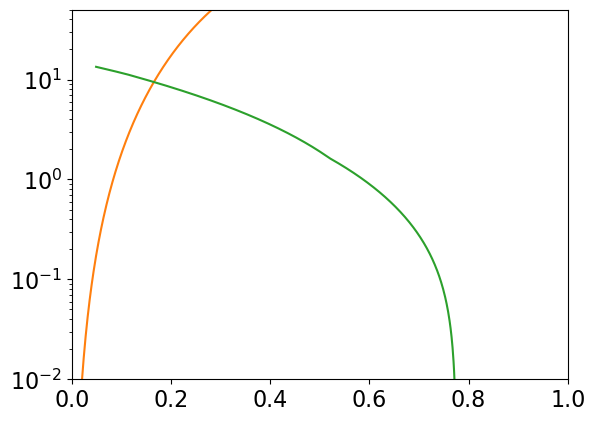

In [18]:
plt.plot(s_vec, bh1)
plt.plot(s_vec, bh2)
plt.semilogy(s_vec, bh3)
plt.ylim([10**-2, 50])
plt.xlim([0,1])

(0.0, 1.0)

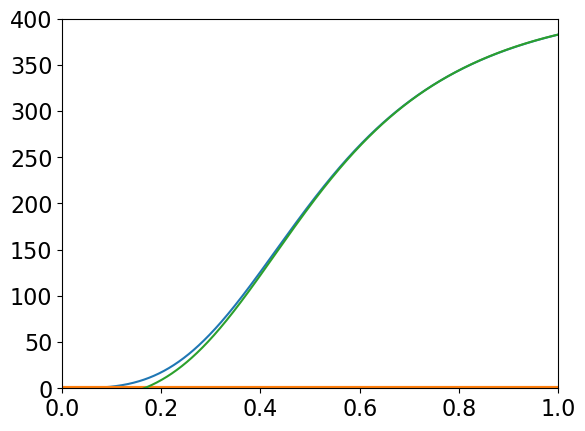

In [17]:
plt.plot(s_vec, bc1)
plt.plot(s_vec, bc2, linewidth = 3)
plt.plot(s_vec, bc3)
plt.ylim([0,400])
plt.xlim([0,1])

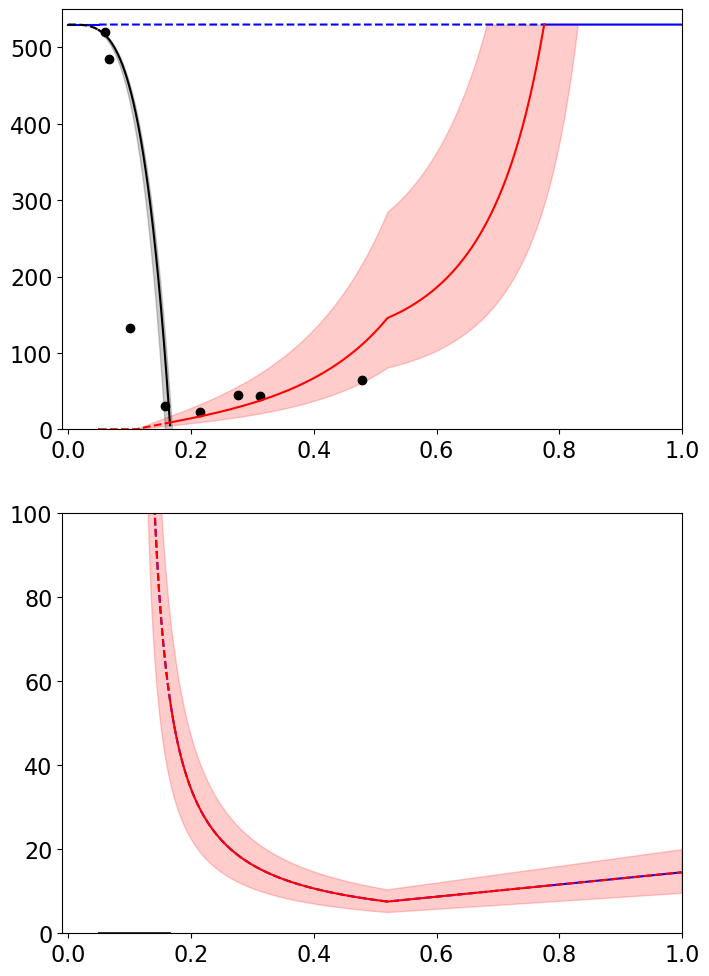

In [16]:
fig, axs = plt.subplots(2, 1, figsize=(8,12))#, sharex=True)
axs[0].plot(s_vec[0:250], h1[0:250], color="blue")
axs[0].plot(s_vec[250:3880], h1[250:3880], color="blue", linestyle="dashed")
axs[0].plot(s_vec[3880:], h1[3880:], color="blue")
axs[0].plot(s_vec[0:250], h2[0:250], color="k", linestyle="dashed")
axs[0].plot(s_vec[250:830], h2[250:830], color="k")
axs[0].plot(s_vec[0:250], h3[0:250], color="red", linestyle="dashed")
axs[0].plot(s_vec[250:830], h3[250:830], color="red", linestyle="dashed")
axs[0].plot(s_vec[830:3880], h3[830:3880], color="red")
axs[0].fill_between(s_vec, h2up, h2low, color = "k", alpha=0.2)
axs[0].fill_between(s_vec, h3up, h3low, color = "red", alpha=0.2)
axs[0].scatter(ss, hh2, color = "k")
axs[0].set_ylim([0,550])
axs[0].set_xlim([-0.01,1])
axs[1].plot(s_vec[560:3880], c1[560:3880], color="blue", linestyle="dashed")
axs[1].plot(s_vec[3880:], c1[3880:], color="blue")
#axs[1].plot(s_vec[0:25], c2[0:25], color="k", linestyle="dashed")
axs[1].plot(s_vec[250:830], c2[250:830], color="k")
axs[1].plot(s_vec[560:830], c3[560:830], color="red", linestyle="dashed")
axs[1].plot(s_vec[830:3880], c3[830:3880], color="red")
axs[1].plot(s_vec[3880:], c3[3880:], color="red", linestyle="dashed")
axs[1].fill_between(s_vec, c2up, c2low, color = "k", alpha=0.2)
axs[1].fill_between(s_vec, c3up, c3low, color = "red", alpha=0.2)
axs[1].set_ylim([0,100])
axs[1].set_xlim([-0.01,1]);

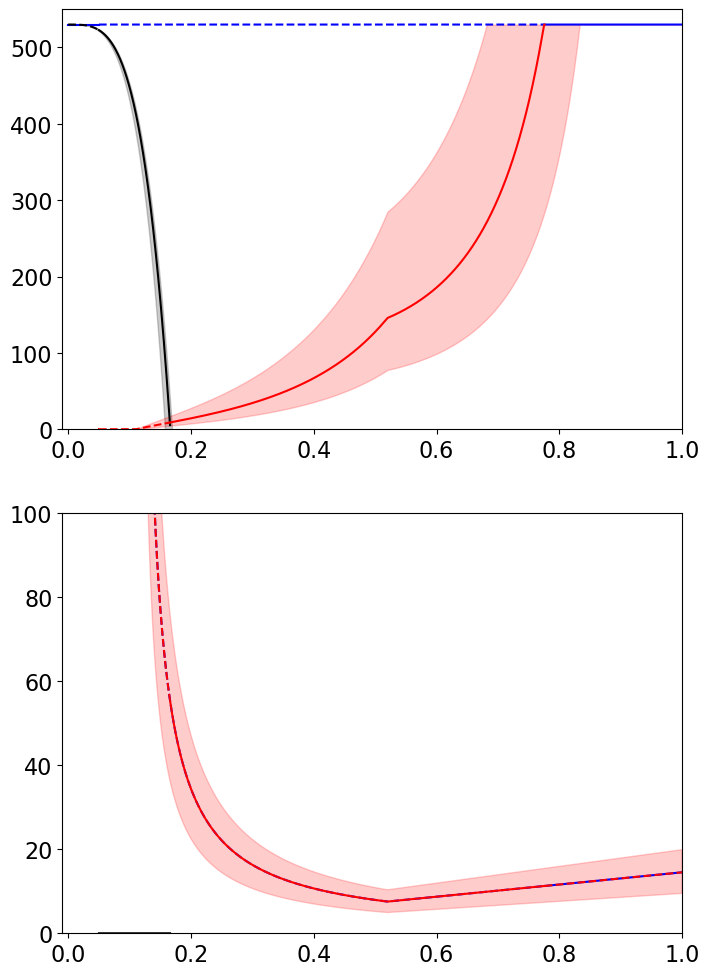

In [25]:
fig, axs = plt.subplots(2, 1, figsize=(8,12))#, sharex=True)
axs[0].plot(s_vec[0:250], h1[0:250], color="blue")
axs[0].plot(s_vec[250:3880], h1[250:3880], color="blue", linestyle="dashed")
axs[0].plot(s_vec[3880:], h1[3880:], color="blue")
axs[0].plot(s_vec[0:250], h2[0:250], color="k", linestyle="dashed")
axs[0].plot(s_vec[250:830], h2[250:830], color="k")
axs[0].plot(s_vec[0:250], h3[0:250], color="red", linestyle="dashed")
axs[0].plot(s_vec[250:830], h3[250:830], color="red", linestyle="dashed")
axs[0].plot(s_vec[830:3880], h3[830:3880], color="red")
axs[0].fill_between(s_vec, h2up, h2low, color = "k", alpha=0.2)
axs[0].fill_between(s_vec, h3up, h3low, color = "red", alpha=0.2)
#axs[0].scatter(ss, hh2, color = "k")
axs[0].set_ylim([0,550])
axs[0].set_xlim([-0.01,1])
axs[1].plot(s_vec[560:3880], c1[560:3880], color="blue", linestyle="dashed")
axs[1].plot(s_vec[3880:], c1[3880:], color="blue")
#axs[1].plot(s_vec[0:25], c2[0:25], color="k", linestyle="dashed")
axs[1].plot(s_vec[250:830], c2[250:830], color="k")
axs[1].plot(s_vec[560:830], c3[560:830], color="red", linestyle="dashed")
axs[1].plot(s_vec[830:3880], c3[830:3880], color="red")
axs[1].plot(s_vec[3880:], c3[3880:], color="red", linestyle="dashed")
axs[1].fill_between(s_vec, c2up, c2low, color = "k", alpha=0.2)
axs[1].fill_between(s_vec, c3up, c3low, color = "red", alpha=0.2)
axs[1].set_ylim([0,100])
axs[1].set_xlim([-0.01,1]);

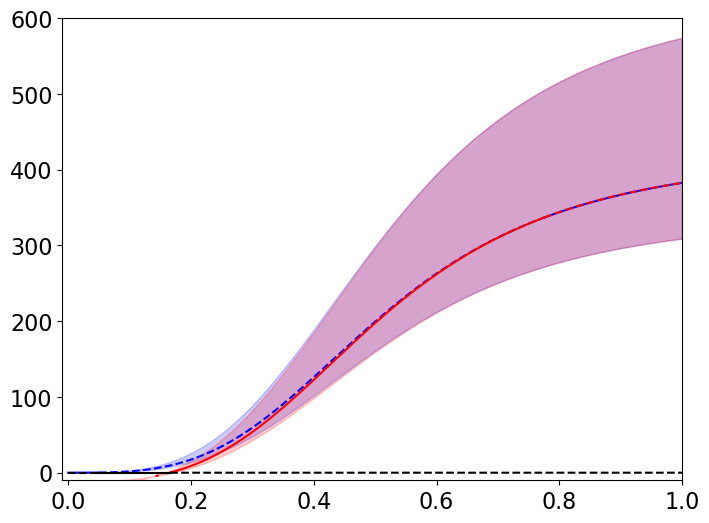

In [17]:
plt.figure(figsize=(8,6))
plt.plot(s_vec[:250], bc1[:250], color="blue")
#plt.plot(s_vec[25:55], bc1[25:55], color="blue", linestyle="dashed")
plt.plot(s_vec[250:3880], bc1[250:3880], color="blue", linestyle="dashed")
plt.plot(s_vec[3880:], bc1[3880:], color="blue")
plt.plot(s_vec[710:740], bc3[710:740], color="red", linestyle="dashed")
plt.plot(s_vec[830:3880], bc3[830:3880], color="red")
plt.plot(s_vec[3880:], bc3[3880:], color="red", linestyle="dashed")
plt.plot(s_vec[0:250], bc2[0:250], color="k", linestyle="dashed")
plt.plot(s_vec[250:830], bc2[250:830], color="k")
plt.plot(s_vec[830:], bc2[830:], color="k", linestyle="dashed")
plt.fill_between(s_vec, bc1up, bc1low, color = "blue", alpha=0.2)
#plt.fill_between(s_vec, bc2up, bc2low, color = "k", alpha=0.2)
plt.fill_between(s_vec, bc3up, bc3low, color = "red", alpha=0.2)
plt.ylim([-10,600])
plt.xlim([-0.01,1]);

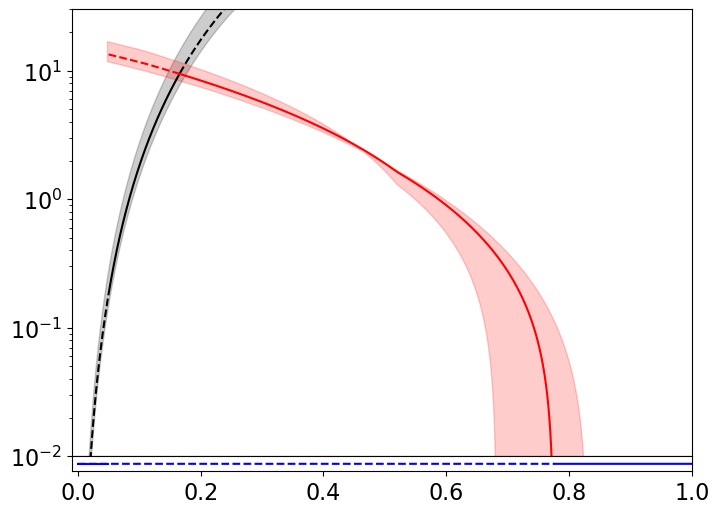

In [18]:
fig, axs = plt.subplots(2, 1, figsize=(8,6), gridspec_kw={'height_ratios': [3, 0.1]})#, sharex=True)
plt.subplots_adjust(hspace=0)
axs[0].semilogy(s_vec[0:250], bh2[0:250], color="k", linestyle="dashed")
axs[0].semilogy(s_vec[250:830], bh2[250:830], color="k")
axs[0].plot(s_vec[830:], bh2[830:], color="k", linestyle="dashed")
axs[0].plot(s_vec[250:830], bh3[250:830], color="red", linestyle="dashed")
axs[0].plot(s_vec[830:3880], bh3[830:3880], color="red")
axs[0].plot(s_vec[3880:], bh3[3880:], color="red", linestyle="dashed")
axs[0].fill_between(s_vec, bh2up, bh2low, color = "k", alpha=0.2)
axs[0].fill_between(s_vec, bh3up, bh3low, color = "red", alpha=0.2)
axs[0].set_ylim([0.01,30])
axs[0].set_xlim([-0.01,1])
axs[0].tick_params(
    axis='x',          # changes apply to the x-axis
    which='both',      # both major and minor ticks are affected
    bottom=False,      # ticks along the bottom edge are off
    top=False,         # ticks along the top edge are off
    labelbottom=False)
#axs[1].plot(s_vec[0:250], bh2[0:250], color="k", linestyle="dashed")
axs[1].plot(s_vec[0:250], bh1[0:250], color="blue")
axs[1].plot(s_vec[:3880], bh1[:3880], color="blue", linestyle="dashed")
axs[1].plot(s_vec[3880:], bh1[3880:], color="blue")
axs[1].set_xlim([-0.01, 1])
axs[1].tick_params(
    axis='y',          # changes apply to the x-axis
    which='both',      # both major and minor ticks are affected
    left=False,      # ticks along the bottom edge are off
    right=False,         # ticks along the top edge are off
    labelleft=False);

In [2]:
df = pd.read_excel("Book2.xlsx", sheet_name="Sheet5") 
df

,s,H1,H2,H3,CS1,CS2,CS3,BC1,BC2,BC3,BH1,BH2,BH3
0,0.000,530,5.300000e+02,530.0,ComplexInfinity,ComplexInfinity,ComplexInfinity,0.000,0,0.000,0,0.000,0.000000
1,0.002,530,5.300000e+02,530.0,ComplexInfinity,ComplexInfinity,ComplexInfinity,0.000,0,0.000,0,0.000,0.000000
2,0.004,530,5.299970e+02,530.0,ComplexInfinity,ComplexInfinity,ComplexInfinity,0.000,0,0.000,0,0.000,0.000000
3,0.006,530,5.299890e+02,530.0,ComplexInfinity,ComplexInfinity,ComplexInfinity,0.000,0,0.000,0,0.000,0.000000
4,0.008,530,5.299710e+02,530.0,ComplexInfinity,ComplexInfinity,ComplexInfinity,0.000,0,0.000,0,0.000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,0.990,530,-3.490770e+09,783348.0,11.7521,-0.002637,11.7521,572.097,0,572.225,0,572.097,-0.128295
496,0.992,530,-6.359520e+09,1351400.0,11.7759,-0.002502,11.7759,572.502,0,572.623,0,572.502,-0.121609
497,0.994,530,-1.377780e+10,2731930.0,11.7996,-0.00234,11.7996,572.903,0,573.017,0,572.903,-0.113576
498,0.996,530,-4.095200e+10,7376010.0,11.8234,-0.00213,11.8234,573.302,0,573.405,0,573.302,-0.103252


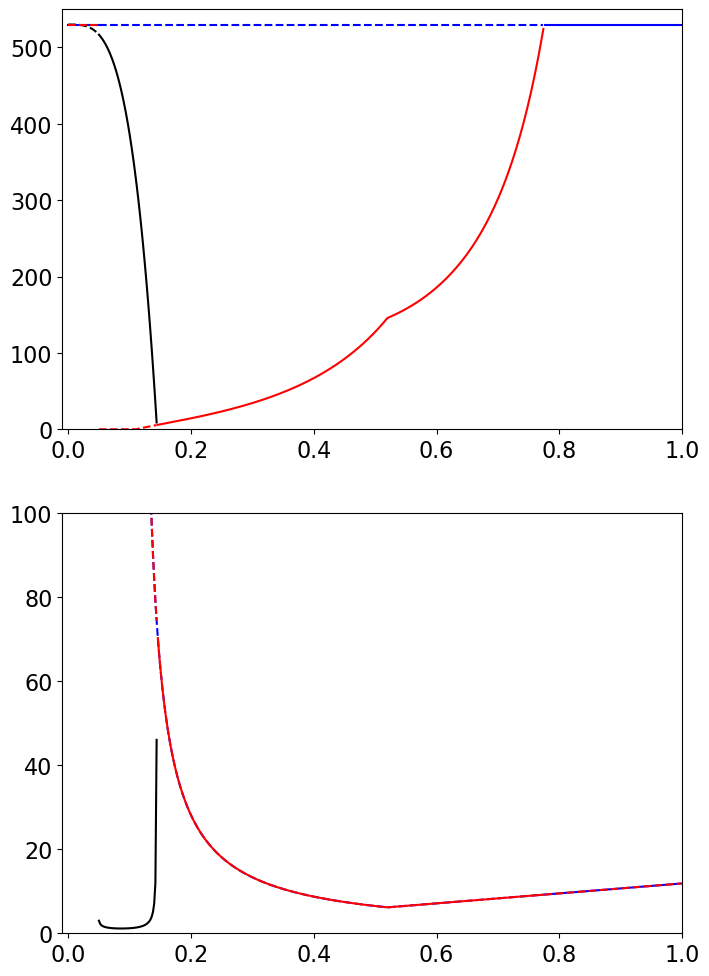

In [9]:
fig, axs = plt.subplots(2, 1, figsize=(8,12))#, sharex=True)
axs[0].plot(df["s"][0:25], df["H1"][0:25], color="blue")
axs[0].plot(df["s"][25:388], df["H1"][25:388], color="blue", linestyle="dashed")
axs[0].plot(df["s"][388:], df["H1"][388:], color="blue")
axs[0].plot(df["s"][0:25], df["H2"][0:25], color="k", linestyle="dashed")
axs[0].plot(df["s"][25:73], df["H2"][25:73], color="k")
axs[0].plot(df["s"][0:25], df["H3"][0:25], color="red", linestyle="dashed")
axs[0].plot(df["s"][25:73], df["H3"][25:73], color="red", linestyle="dashed")
axs[0].plot(df["s"][73:388], df["H3"][73:388], color="red")
axs[0].set_ylim([0,550])
axs[0].set_xlim([-0.01,1])
axs[1].plot(df["s"][56:388], df["CS1"][56:388], color="blue", linestyle="dashed")
axs[1].plot(df["s"][388:], df["CS1"][388:], color="blue")
#axs[1].plot(df["s"][0:25], df["CS2"][0:25], color="k", linestyle="dashed")
axs[1].plot(df["s"][25:73], df["CS2"][25:73], color="k")
axs[1].plot(df["s"][56:73], df["CS3"][56:73], color="red", linestyle="dashed")
axs[1].plot(df["s"][73:388], df["CS3"][73:388], color="red")
axs[1].plot(df["s"][388:], df["CS3"][388:], color="red", linestyle="dashed")
axs[1].set_ylim([0,100])
axs[1].set_xlim([-0.01,1]);

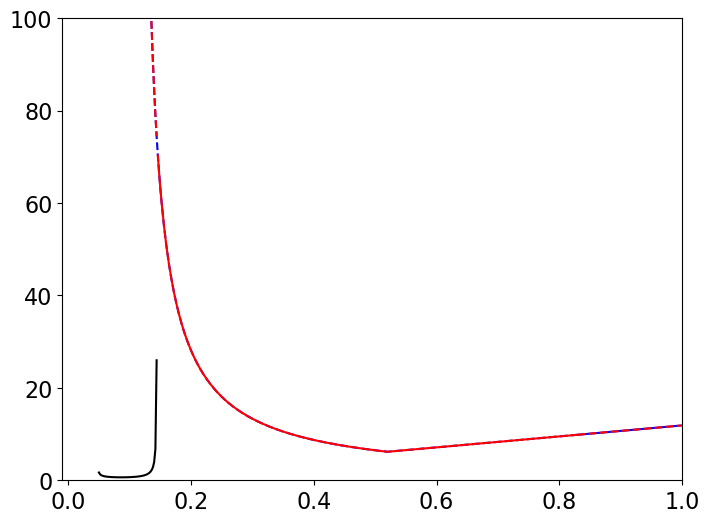

In [54]:
plt.figure(figsize=(8,6))
plt.plot(df["s"][56:415], df["CS1"][56:415], color="blue", linestyle="dashed")
plt.plot(df["s"][415:], df["CS1"][415:], color="blue")
#plt.plot(df["s"][0:25], df["CS2"][0:25], color="k", linestyle="dashed")
plt.plot(df["s"][25:73], df["CS2"][25:73], color="k")
plt.plot(df["s"][56:73], df["CS3"][56:73], color="red", linestyle="dashed")
plt.plot(df["s"][73:415], df["CS3"][73:415], color="red")
plt.plot(df["s"][415:], df["CS3"][415:], color="red", linestyle="dashed")
plt.ylim([0,100])
plt.xlim([-0.01,1]);

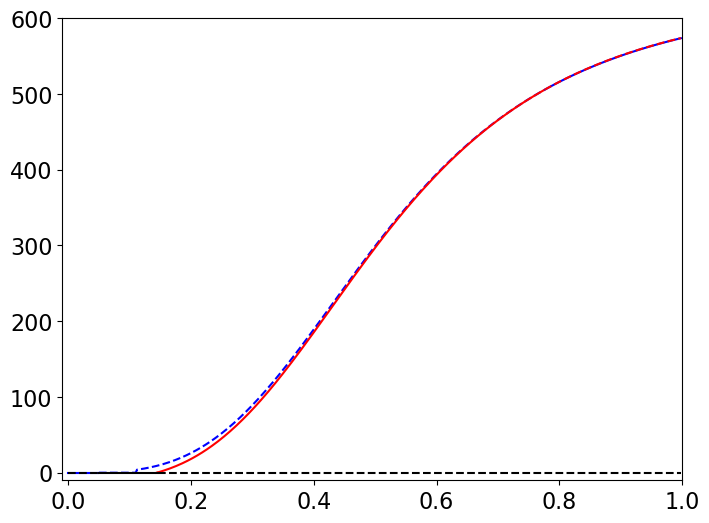

In [8]:
plt.figure(figsize=(8,6))
plt.plot(df["s"][:25], df["BC1"][:25], color="blue")
#plt.plot(df["s"][25:55], df["BC1"][25:55], color="blue", linestyle="dashed")
plt.plot(df["s"][25:388], df["BC1"][25:388], color="blue", linestyle="dashed")
plt.plot(df["s"][388:], df["BC1"][388:], color="blue")
plt.plot(df["s"][71:74], df["BC3"][71:74], color="red", linestyle="dashed")
plt.plot(df["s"][73:388], df["BC3"][73:388], color="red")
plt.plot(df["s"][388:], df["BC3"][388:], color="red", linestyle="dashed")
plt.plot(df["s"][0:25], df["BC2"][0:25], color="k", linestyle="dashed")
plt.plot(df["s"][25:73], df["BC2"][25:73], color="k")
plt.plot(df["s"][73:], df["BC2"][73:], color="k", linestyle="dashed")
plt.ylim([-10,600])
plt.xlim([-0.01,1]);

In [16]:
df["BC1"][53:57]

53    0.00000
54    0.00000
55    0.00000
56    3.94851
Name: BC1, dtype: float64

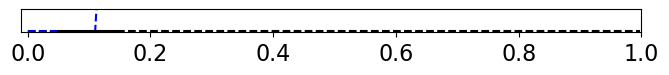

In [23]:
plt.figure(figsize=(8,0.3))
plt.plot(df["s"][0:25], df["BC2"][0:25], color="k", linestyle="dashed")
plt.plot(df["s"][:57], df["BC1"][:57], color="blue", linestyle="dashed")
plt.plot(df["s"][25:73], df["BC2"][25:73], color="k")
plt.plot(df["s"][73:], df["BC2"][73:], color="k", linestyle="dashed")
#plt.ylim([-0.1,0.1])
plt.xlim([-0.01, 1])
plt.tick_params(
    axis='y',          # changes apply to the x-axis
    which='both',      # both major and minor ticks are affected
    left=False,      # ticks along the bottom edge are off
    right=False,         # ticks along the top edge are off
    labelleft=False);

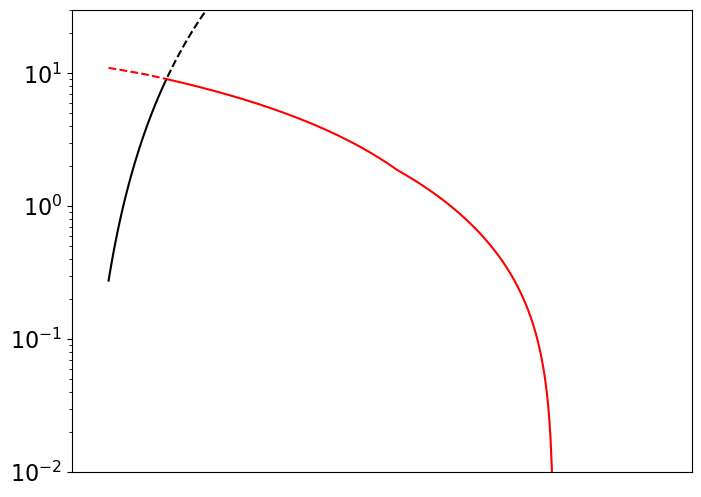

In [5]:
plt.figure(figsize=(8,6))
#plt.semilogy(df["s"][0:25], df["BH2"][0:25], color="k", linestyle="dashed")
plt.semilogy(df["s"][25:73], df["BH2"][25:73], color="k")
plt.plot(df["s"][73:], df["BH2"][73:], color="k", linestyle="dashed")
plt.plot(df["s"][25:73], df["BH3"][25:73], color="red", linestyle="dashed")
plt.plot(df["s"][73:388], df["BH3"][73:388], color="red")
plt.plot(df["s"][388:], df["BH3"][388:], color="red", linestyle="dashed")
plt.ylim([0.01,30])
plt.xlim([-0.01,1])
plt.tick_params(
    axis='x',          # changes apply to the x-axis
    which='both',      # both major and minor ticks are affected
    bottom=False,      # ticks along the bottom edge are off
    top=False,         # ticks along the top edge are off
    labelbottom=False);

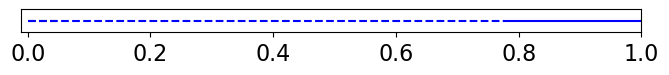

In [45]:
plt.figure(figsize=(8,0.3))
plt.plot(df["s"][0:25], df["BH2"][0:25], color="k", linestyle="dashed")
plt.plot(df["s"][:388], df["BH1"][:388], color="blue", linestyle="dashed")
plt.plot(df["s"][388:], df["BH1"][388:], color="blue")
plt.xlim([-0.01, 1])
plt.tick_params(
    axis='y',          # changes apply to the x-axis
    which='both',      # both major and minor ticks are affected
    left=False,      # ticks along the bottom edge are off
    right=False,         # ticks along the top edge are off
    labelleft=False);

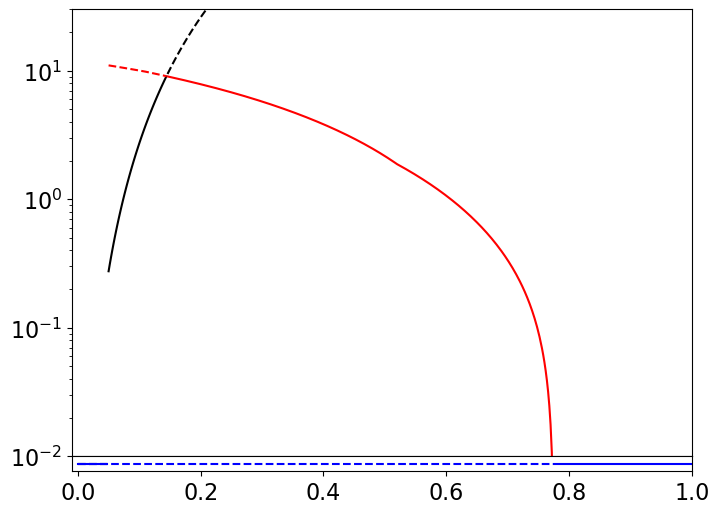

In [7]:
fig, axs = plt.subplots(2, 1, figsize=(8,6), gridspec_kw={'height_ratios': [3, 0.1]})#, sharex=True)
plt.subplots_adjust(hspace=0)
axs[0].semilogy(df["s"][0:25], df["BH2"][0:25], color="k", linestyle="dashed")
axs[0].semilogy(df["s"][25:73], df["BH2"][25:73], color="k")
axs[0].plot(df["s"][73:], df["BH2"][73:], color="k", linestyle="dashed")
axs[0].plot(df["s"][25:73], df["BH3"][25:73], color="red", linestyle="dashed")
axs[0].plot(df["s"][73:388], df["BH3"][73:388], color="red")
axs[0].plot(df["s"][388:], df["BH3"][388:], color="red", linestyle="dashed")
axs[0].set_ylim([0.01,30])
axs[0].set_xlim([-0.01,1])
axs[0].tick_params(
    axis='x',          # changes apply to the x-axis
    which='both',      # both major and minor ticks are affected
    bottom=False,      # ticks along the bottom edge are off
    top=False,         # ticks along the top edge are off
    labelbottom=False)
axs[1].plot(df["s"][0:25], df["BH2"][0:25], color="k", linestyle="dashed")
axs[1].plot(df["s"][0:25], df["BH1"][0:25], color="blue")
axs[1].plot(df["s"][:388], df["BH1"][:388], color="blue", linestyle="dashed")
axs[1].plot(df["s"][388:], df["BH1"][388:], color="blue")
axs[1].set_xlim([-0.01, 1])
axs[1].tick_params(
    axis='y',          # changes apply to the x-axis
    which='both',      # both major and minor ticks are affected
    left=False,      # ticks along the bottom edge are off
    right=False,         # ticks along the top edge are off
    labelleft=False);

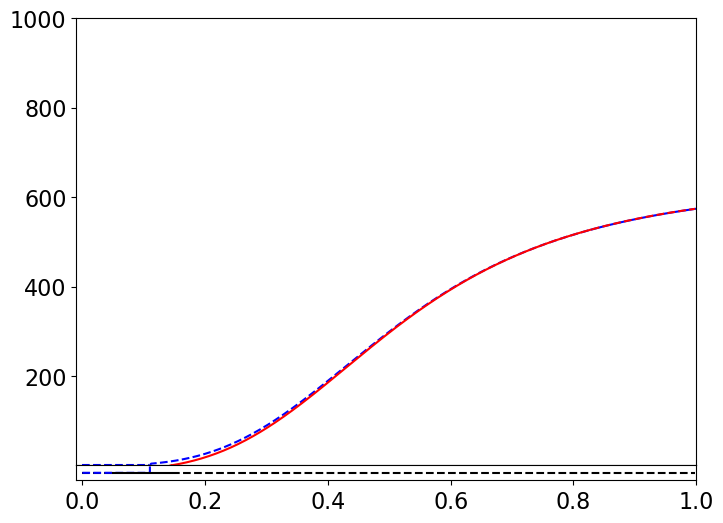

In [28]:
fig, axs = plt.subplots(2, 1, figsize=(8,6), gridspec_kw={'height_ratios': [3, 0.1]})#, sharex=True)
plt.subplots_adjust(hspace=0)
axs[0].plot(df["s"][:55], df["BC1"][:55], color="blue", linestyle="dashed")
axs[0].plot(df["s"][55:415], df["BC1"][55:415], color="blue", linestyle="dashed")
axs[0].plot(df["s"][415:], df["BC1"][415:], color="blue")
axs[0].plot(df["s"][71:74], df["BC3"][71:74], color="red", linestyle="dashed")
axs[0].plot(df["s"][73:415], df["BC3"][73:415], color="red")
axs[0].plot(df["s"][415:], df["BC3"][415:], color="red", linestyle="dashed")
axs[0].set_ylim([0.1,1000])
axs[0].set_xlim([-0.01,1])
axs[0].tick_params(
    axis='x',          # changes apply to the x-axis
    which='both',      # both major and minor ticks are affected
    bottom=False,      # ticks along the bottom edge are off
    top=False,         # ticks along the top edge are off
    labelbottom=False)
axs[1].plot(df["s"][0:25], df["BC2"][0:25], color="k", linestyle="dashed")
axs[1].plot(df["s"][:57], df["BC1"][:57], color="blue", linestyle="dashed")
axs[1].plot(df["s"][25:73], df["BC2"][25:73], color="k")
axs[1].plot(df["s"][73:], df["BC2"][73:], color="k", linestyle="dashed")
axs[1].set_ylim([-0.1,0.1])
axs[1].set_xlim([-0.01, 1])
axs[1].tick_params(
    axis='y',          # changes apply to the x-axis
    which='both',      # both major and minor ticks are affected
    left=False,      # ticks along the bottom edge are off
    right=False,         # ticks along the top edge are off
    labelleft=False);

In [26]:
h2 = pd.read_excel("H2 havard forest.xlsx", sheet_name="Sheet1")
h2

,year,date,doy,ss_dry,ss_mean,ss_wet,vd
0,2010,2010-12-01,335,0.369579,0.550202,0.730825,0.011101
1,2010,2010-12-02,336,0.430260,0.621698,0.813135,0.007736
2,2010,2010-12-03,337,0.400260,0.578987,0.757714,0.011260
3,2010,2010-12-04,338,0.382459,0.562157,0.741855,0.014708
4,2010,2010-12-05,339,0.374777,0.554248,0.733719,0.009308
...,...,...,...,...,...,...,...
451,2012,2012-02-25,56,0.410413,0.633370,0.856328,0.003156
452,2012,2012-02-26,57,0.419393,0.603820,0.788246,0.003941
453,2012,2012-02-27,58,0.393720,0.582403,0.771086,0.002856
454,2012,2012-02-28,59,0.381465,0.596135,0.810805,0.004516
